<a href="https://colab.research.google.com/github/2403a54127-lab/-PRODIGY_WD_04-/blob/main/PRODIGY_WD_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Dataset Shape: (74682, 4)
     ID        Topic Sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                               Tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  

Missing Values:
ID             0
Topic          0
Sentiment      0
Tweet          0
Clean_Tweet    0
dtype: int64


/tmp/ipykernel_5447/945812128.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


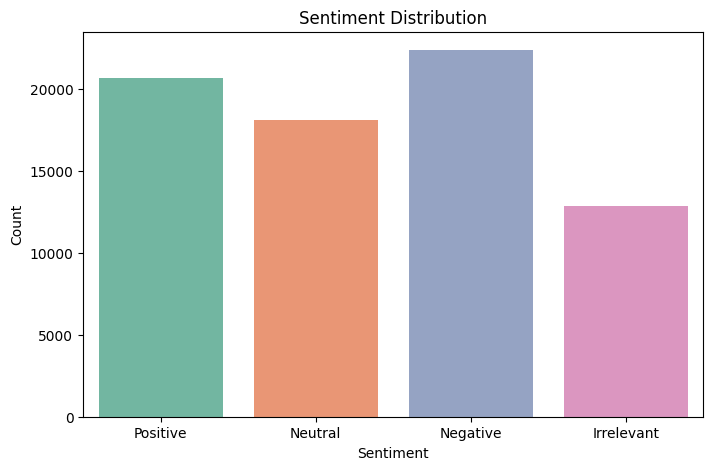

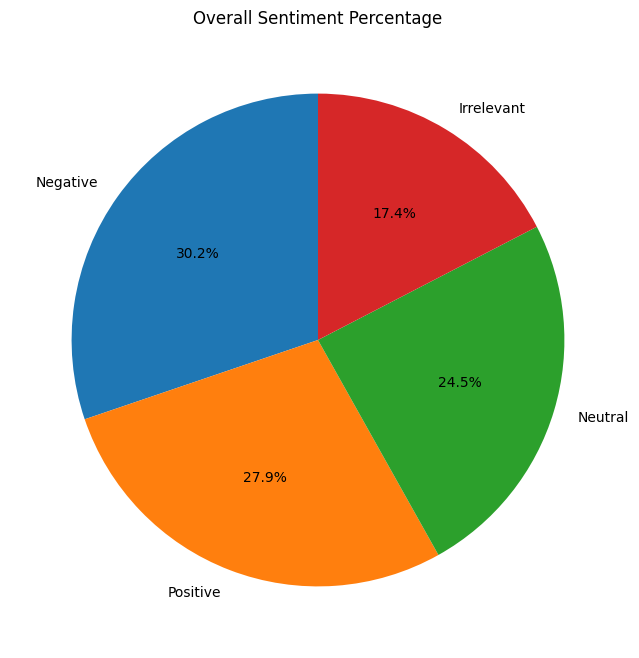

/tmp/ipykernel_5447/945812128.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


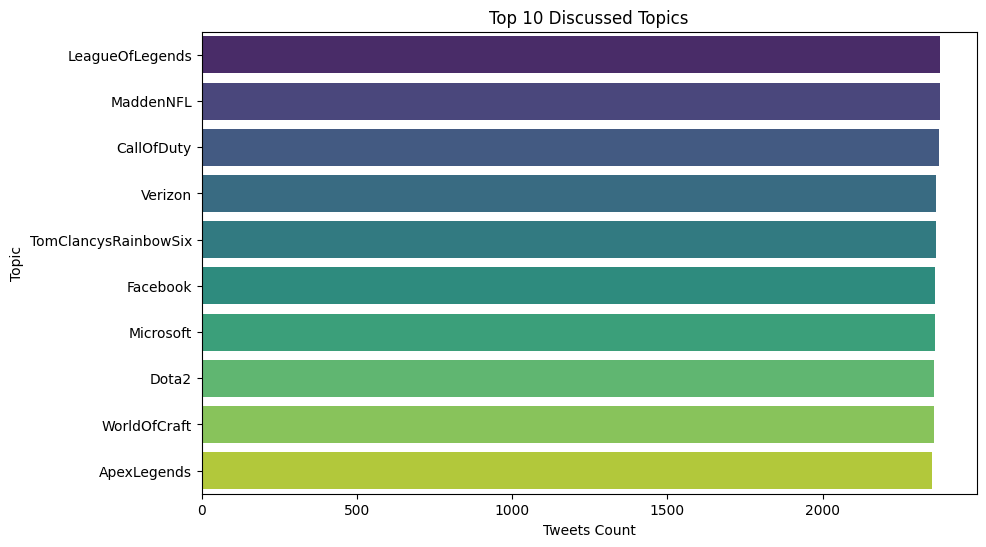

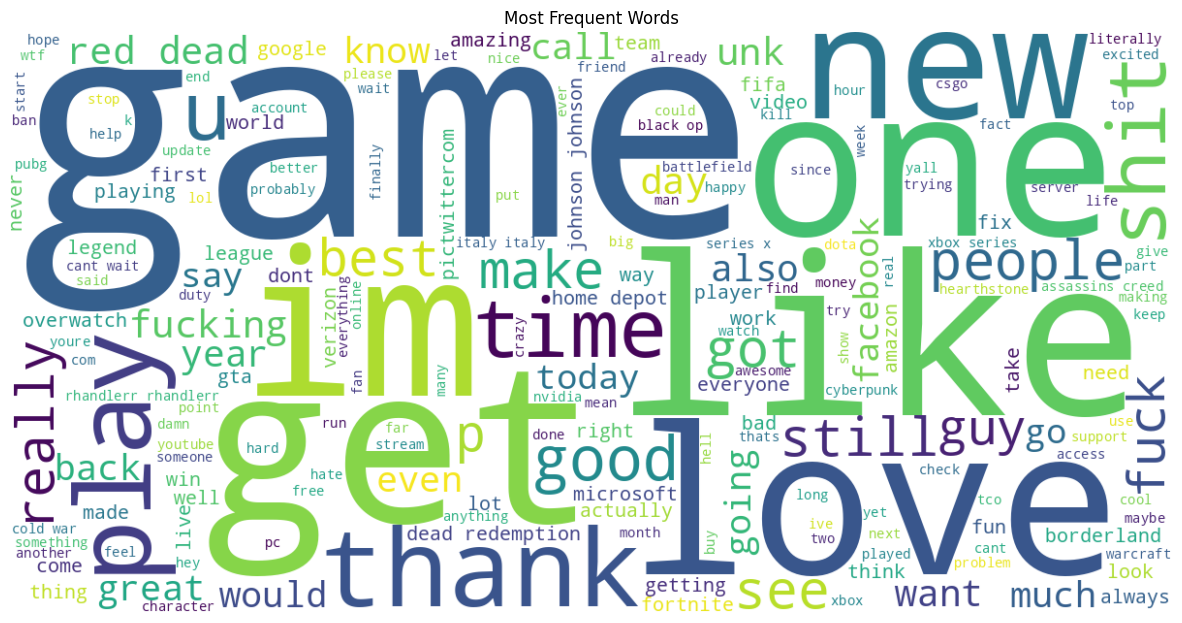

/tmp/ipykernel_5447/945812128.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


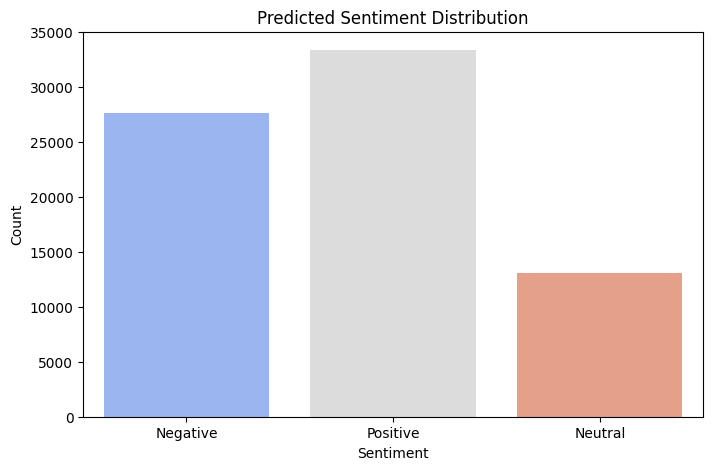

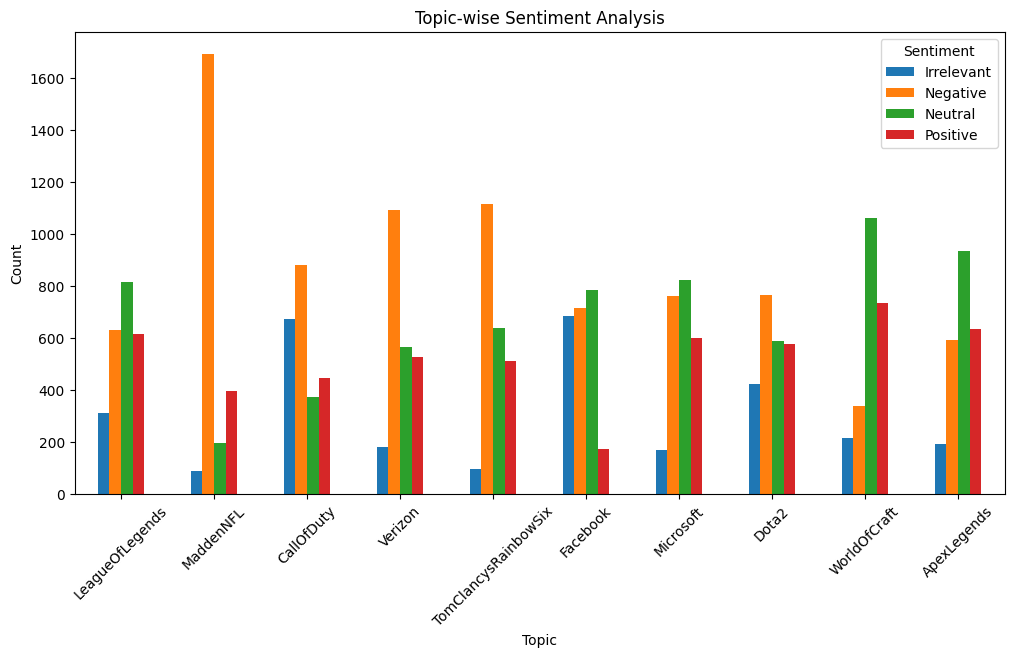

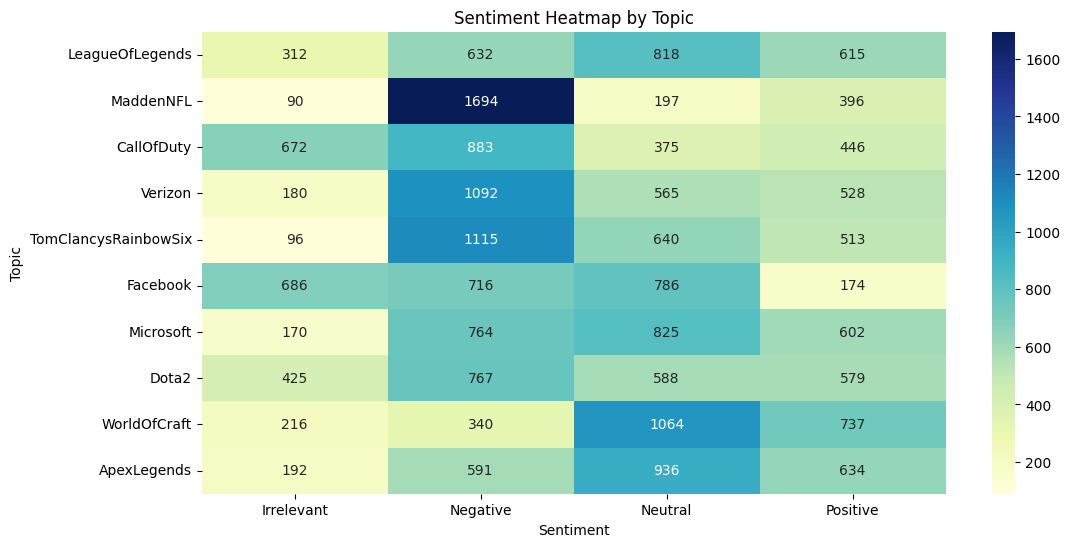


Analysis Completed Successfully!
Output saved as Sentiment_Analysis_Output.csv


In [10]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
import re

nltk.download('stopwords')
nltk.download('vader_lexicon')

# =====================================
# Load Dataset
# =====================================

df = pd.read_csv("/content/twitter_training.csv.zip", header=None)

# Rename columns
df.columns = ["ID", "Topic", "Sentiment", "Tweet"]

print("Dataset Shape:", df.shape)

# Display first rows
print(df.head())

# =====================================
# Data Cleaning
# =====================================

df.dropna(inplace=True)

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

df['Clean_Tweet'] = df['Tweet'].apply(clean_text)

print("\nMissing Values:")
print(df.isnull().sum())

# =====================================
# Sentiment Distribution
# =====================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df,
    palette='Set2'
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# =====================================
# Pie Chart
# =====================================

sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Overall Sentiment Percentage")
plt.show()

# =====================================
# Most Discussed Topics
# =====================================

top_topics = df['Topic'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_topics.values,
    y=top_topics.index,
    palette='viridis'
)

plt.title("Top 10 Discussed Topics")
plt.xlabel("Tweets Count")
plt.ylabel("Topic")

plt.show()

# =====================================
# Word Cloud
# =====================================

stop_words = set(stopwords.words('english'))

text = " ".join(df['Clean_Tweet'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stop_words
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.title("Most Frequent Words")
plt.show()

# =====================================
# VADER Sentiment Analysis
# =====================================

sia = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    return sia.polarity_scores(text)['compound']

df['Sentiment_Score'] = df['Clean_Tweet'].apply(get_sentiment_score)

def classify(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Predicted_Sentiment'] = df['Sentiment_Score'].apply(classify)

# =====================================
# Predicted Sentiment Distribution
# =====================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Predicted_Sentiment',
    data=df,
    palette='coolwarm'
)

plt.title("Predicted Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# =====================================
# Topic-wise Sentiment Analysis
# =====================================

topic_sentiment = pd.crosstab(
    df['Topic'],
    df['Sentiment']
)

top10_topics = df['Topic'].value_counts().head(10).index

topic_sentiment = topic_sentiment.loc[top10_topics]

topic_sentiment.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Topic-wise Sentiment Analysis")
plt.xlabel("Topic")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# =====================================
# Heatmap
# =====================================

plt.figure(figsize=(12,6))

sns.heatmap(
    topic_sentiment,
    annot=True,
    cmap='YlGnBu',
    fmt='d'
)

plt.title("Sentiment Heatmap by Topic")

plt.show()

# =====================================
# Save Processed Dataset
# =====================================

df.to_csv(
    "Sentiment_Analysis_Output.csv",
    index=False
)

print("\nAnalysis Completed Successfully!")
print("Output saved as Sentiment_Analysis_Output.csv")